BM25: red=0.108, cov=0.586
MMR: red=0.103, cov=0.587
Random: red=0.088, cov=0.440
Llama: red=0.103, cov=0.496
Qwen: red=0.110, cov=0.529
GPT: red=0.119, cov=0.536


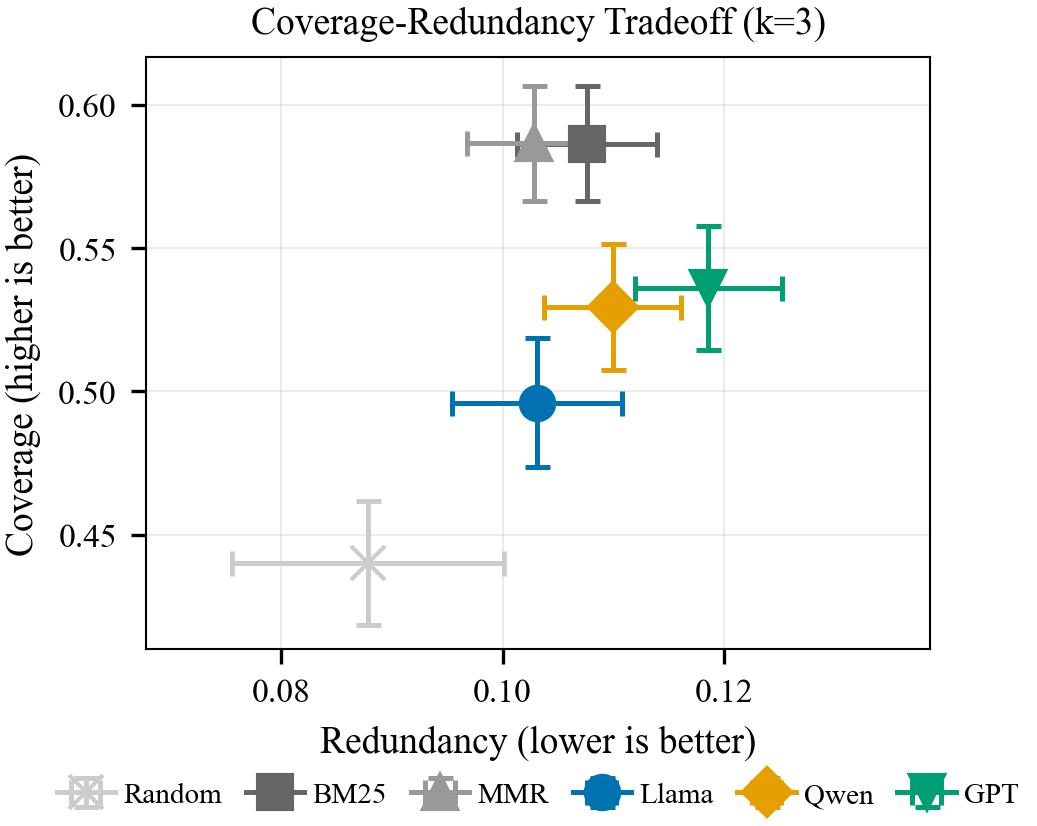

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import Path

RUN_ROOT = Path.cwd() / "runs_fixed_pool_rerank"

PREP_ROWS_PATH = os.path.join(RUN_ROOT, "prep_20260201_185037\prep_rows.jsonl")

RUNS = {
    "Llama": os.path.join(RUN_ROOT, "exp1_llama_20260131_140548"),
    "Qwen": os.path.join(RUN_ROOT, "exp1_qwen_20260131_143032"),
    "GPT": os.path.join(RUN_ROOT, "exp1_gpt_20260131_154255"),
}

K_VALUE = 3


def read_jsonl(path):
    out = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                out.append(json.loads(line))
    return out


flat_by_run = {}
for name, run_dir in RUNS.items():
    flat_by_run[name] = read_jsonl(os.path.join(run_dir, "results_by_keep_flat.jsonl"))

llama_flat = flat_by_run["Llama"]
rows_k = [r for r in llama_flat if int(r["keep"]) == K_VALUE]

data = {
    "BM25": {
        "red": np.array([r["bm25_red_cont"] for r in rows_k]),
        "cov": np.array([r["bm25_cov_cont"] for r in rows_k]),
    },
    "MMR": {
        "red": np.array([r["mmr_red_cont"] for r in rows_k]),
        "cov": np.array([r["mmr_cov_cont"] for r in rows_k]),
    },
    "Random": {
        "red": np.array([r["rand_red_cont"] for r in rows_k]),
        "cov": np.array([r["rand_cov_cont"] for r in rows_k]),
    },
}

for name in ["Llama", "Qwen", "GPT"]:
    flat = flat_by_run[name]
    rows = [r for r in flat if int(r["keep"]) == K_VALUE]
    data[name] = {
        "red": np.array([r["llm_red_cont"] for r in rows]),
        "cov": np.array([r["llm_cov_cont"] for r in rows]),
    }

for name in data:
    print(f"{name}: red={np.mean(data[name]['red']):.3f}, cov={np.mean(data[name]['cov']):.3f}")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.linewidth": 0.5,
})

COLORS = {
    "BM25": "#666666",
    "MMR": "#999999",
    "Random": "#cccccc",
    "Llama": "#0072B2",
    "Qwen": "#E69F00",
    "GPT": "#009E73",
}

MARKERS = {
    "BM25": "s",
    "MMR": "^",
    "Random": "x",
    "Llama": "o",
    "Qwen": "D",
    "GPT": "v",
}

METHOD_ORDER = ["Random", "BM25", "MMR", "Llama", "Qwen", "GPT"]

fig, ax = plt.subplots(figsize=(3.5, 2.8), constrained_layout=True)

for name in METHOD_ORDER:
    mean_red = np.mean(data[name]["red"])
    mean_cov = np.mean(data[name]["cov"])
    std_red = np.std(data[name]["red"]) / np.sqrt(len(data[name]["red"]))
    std_cov = np.std(data[name]["cov"]) / np.sqrt(len(data[name]["cov"]))
    
    ax.errorbar(
        mean_red, mean_cov,
        xerr=std_red * 1.96,
        yerr=std_cov * 1.96,
        marker=MARKERS[name],
        markersize=8,
        color=COLORS[name],
        capsize=3,
        capthick=1.2,
        linewidth=1.2,
        label=name,
        zorder=3,
    )

ax.set_xlabel("Redundancy (lower is better)")
ax.set_ylabel("Coverage (higher is better)")
ax.set_title(f"Coverage-Redundancy Tradeoff (k={K_VALUE})")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    frameon=False,
    ncol=6,
    columnspacing=0.8,
    handletextpad=0.3,
)

ax.grid(True, alpha=0.3, linewidth=0.4, zorder=0)

all_red = np.concatenate([data[n]["red"] for n in data])
all_cov = np.concatenate([data[n]["cov"] for n in data])
means_red = [np.mean(data[n]["red"]) for n in data]
means_cov = [np.mean(data[n]["cov"]) for n in data]

pad_x = 0.02
pad_y = 0.03
ax.set_xlim(min(means_red) - pad_x, max(means_red) + pad_x)
ax.set_ylim(min(means_cov) - pad_y, max(means_cov) + pad_y)

plt.savefig("fig_tradeoff_clean.pdf")
plt.savefig("fig_tradeoff_clean.png", dpi=300)
plt.show()